## Baseline similarity matching (RR monthly vs ensemble consensus, DuckDB/Parquet)

Every daily transcription (ensemble file) is matched to the Rainfall-Rescue
monthly records by comparing month-by-month values:

- RR vectors: station-year monthly profiles from monthly_rainfall
- Ensemble vectors: monthly values from all 5 ensemble members
- Primary score: count of months where RR equals any ensemble member
  (after rounding both values to 2 decimal places)
- Tie-breaker: higher overlap-month count
- Compatibility fields: cosine and adjusted score are still stored
  for diagnostics and historical comparability

The cell below runs this matcher interactively on a bounded slice so the
notebook stays fast. Use the SLURM scripts for full-scale matching.

In [9]:
# Setup parquet roots for RR, ensemble, and similarity datasets.

import os
from pathlib import Path

from src.rainfall_rescue_sqlite.ingest import default_db_path
from src.rainfall_rescue_sqlite.ensemble_ingest import default_ensemble_db_path
from src.rainfall_rescue_sqlite.parquet_ingest import (
    default_ensemble_parquet_root,
    default_rainfall_rescue_parquet_root,
 )
from src.rainfall_rescue_sqlite.parquet_similarity import default_comparison_parquet_root

# Parquet roots for the replatformed pipeline.
rr_dataset_root = default_rainfall_rescue_parquet_root()
ensemble_dataset_root = default_ensemble_parquet_root()
comparison_root = default_comparison_parquet_root()

# Legacy SQLite paths kept for downstream legacy sections in this notebook.
db_path = default_db_path()
ensemble_db_path = default_ensemble_db_path()
comparison_db_path = Path(f"{os.getenv('PDIR')}/monthly_similarity.sqlite")

rr_dataset_root, ensemble_dataset_root, comparison_root

(PosixPath('/data/scratch/philip.brohan/ADRQ/Rainfall-Rescue/rainfall_rescue_parquet'),
 PosixPath('/data/scratch/philip.brohan/ADRQ/ensemble_transcriptions_parquet'),
 PosixPath('/data/scratch/philip.brohan/ADRQ/monthly_similarity_parquet'))

In [ ]:
# Build comparison vectors from RR + ensemble parquet datasets.
#
# MEMORY NOTE: this step loads all RR vectors (~285k station-years) and all
# ensemble consensus vectors (~514k files) into Python memory to compute
# monthly medians and IQRs before writing them to parquet. On the full dataset
# that requires ~8-16 GB RAM, so it should normally be run on the cluster
# via the SLURM build job (scripts/slurm/build_vectors.sbatch), not here.
#
# Set rebuild_vectors = True only if you want to (re)build from scratch on
# this machine. If comparison_root already contains vectors from a cluster run,
# leave it False and go straight to the matching cell below.

from src.rainfall_rescue_sqlite.parquet_similarity import build_comparison_vectors_parquet

rebuild_vectors = False  # <-- set True to rebuild; leave False after a cluster build

if rebuild_vectors:
    build_result = build_comparison_vectors_parquet(
        rr_dataset_root=rr_dataset_root,
        ensemble_dataset_root=ensemble_dataset_root,
        comparison_root=comparison_root,
    )
    print(build_result)
else:
    rr_vec_path = comparison_root / "rr_monthly_vectors"
    ens_vec_path = comparison_root / "ensemble_consensus_vectors"
    if rr_vec_path.exists() and ens_vec_path.exists():
        print(f"Skipping build — vectors already present in {comparison_root}")
    else:
        print(
            "WARNING: comparison_root has no vectors yet.\n"
            "Either set rebuild_vectors = True (needs ~8-16 GB RAM for full dataset),\n"
            "or run the cluster build job first:\n"
            "  scripts/slurm/submit_all.sh"
        )

In [ ]:
# Run bounded similarity matching against existing comparison vectors.
#
# max_ensemble_queries and max_rr_candidates cap how many vectors are loaded,
# so this cell is safe to run on a workstation regardless of dataset size.
# The matching itself keeps only the RR candidate matrix in RAM (~27 MB for
# 285k candidates) and streams ensemble queries — it does not load all vectors.
#
# For a full-scale run use the SLURM matching pipeline instead
# (scripts/slurm/submit_all.sh), which parallelises the queries across shards.

from src.rainfall_rescue_sqlite.parquet_similarity import run_baseline_matching_parquet

match_result = run_baseline_matching_parquet(
    comparison_root=comparison_root,
    top_k=10,
    min_overlap=10,
    uncertainty_weight=0.15,
    max_ensemble_queries=200,    # remove limits for full-scale cluster run
    max_rr_candidates=20000,
)

print(match_result)

In [7]:
# Inspect top exact matches from the latest parquet similarity session.

import duckdb

conn = duckdb.connect()
try:
    latest_session = conn.execute(
        f"SELECT MAX(session_id) FROM read_parquet('{comparison_root / 'similarity_sessions' / '*.parquet'}')"
    ).fetchone()[0]

    rows = conn.execute(
        f"""
        SELECT
            m.query_rank,
            m.exact_agreement_count,
            m.adjusted_score,
            m.cosine_similarity,
            m.overlap_months,
            m.ensemble_uncertainty,
            e.file_name,
            e.descriptor,
            r.station_file_id,
            r.year,
            r.location_name
        FROM read_parquet('{comparison_root / 'similarity_matches' / '*.parquet'}') m
        JOIN read_parquet('{comparison_root / 'ensemble_consensus_vectors' / '*.parquet'}') e
          ON e.ensemble_vector_id = m.ensemble_vector_id
        JOIN read_parquet('{comparison_root / 'rr_monthly_vectors' / '*.parquet'}') r
          ON r.rr_vector_id = m.rr_vector_id
        WHERE m.session_id = ?
          AND m.query_rank = 1
          AND m.exact_agreement_count = 9
        ORDER BY m.adjusted_score DESC
        LIMIT 20
        """
        , [latest_session]
    ).fetchall()
finally:
    conn.close()

print(f"Latest session: {latest_session}")
for row in rows:
    print(
        f"rank={row[0]:>2}  exact={row[1]:>2}  "
        f"overlap={row[4]:>2}  score={row[2]:.4f}  "
        f"cos={row[3]:.4f}  "
        f"unc={row[5] if row[5] is not None else 'n/a'}  "
        f"ensemble={row[6]}  rr={row[8]}:{row[9]}  "
        f"loc={row[10] or 'n/a'}"
    )

Latest session: 1
rank= 1  exact= 9  overlap=12  score=0.9992  cos=0.9999  unc=0.0050000000000000044  ensemble=DRain_1951-1962_RainNos_0001-0045-284.json  rr=KENSINGTON-PALACE/KENSINGTON-PALACE:1958  loc=KENSINGTON-PALACE
rank= 1  exact= 9  overlap=12  score=0.9992  cos=0.9999  unc=0.0050000000000000044  ensemble=DRain_1951-1962_RainNos_1-45_B027-12.json  rr=KENSINGTON-PALACE/KENSINGTON-PALACE:1958  loc=KENSINGTON-PALACE
rank= 1  exact= 9  overlap=12  score=0.9985  cos=0.9997  unc=0.00833333333333334  ensemble=DRain_1931-1940_RainNos_3540-3572-340.json  rr=TYNEMOUTH-COASTGUARD-STN/TYNEMOUTH-COASTGUARD-STN-2:1931  loc=TYNEMOUTH COASTGUARD STATION (OLD GAUGE)
rank= 1  exact= 9  overlap=12  score=0.9980  cos=0.9999  unc=0.01250000000000003  ensemble=DRain_1921-1930_RainNos_Yorkshire_Castleton_to_Guisborough_B007-5.json  rr=CONISBROUGH-FIRSBY-RES/CONISBROUGH-FIRSBY-RES:1925  loc=CONISBROUGH FIRSBY RESERVOIR
rank= 1  exact= 9  overlap=12  score=0.9971  cos=0.9999  unc=0.019166666666666655  

## Full-scale matching with SLURM

The interactive matching above only processes a small slice. To match **every**
ensemble file against **every** RR station-year the work is split into shards
and run as a SLURM array job on the SPICE cluster. All scripts use the
**DuckDB/Parquet** backend by default.

**How the work is sharded**

- A single **build** job reads all RR vectors (~285 k station-years) and all
  ensemble consensus vectors (~514 k files) from the parquet datasets and
  writes normalised vector parquet files to `$COMPARISON_PARQUET_ROOT`.
  (This is the RAM-intensive step — ~8–16 GB — so it always runs on the
  cluster rather than interactively.)
- The ensemble queries are divided into `NUM_SHARDS` (default 100) contiguous
  slices (by `ORDER BY ensemble_vector_id`). Each shard matches its own slice
  against *all* RR candidates and writes its top-K results to a private
  `similarity_shard_XXXXX.parquet` file in `$SIMILARITY_SHARD_DIR`.
  Each shard only needs the RR candidate matrix (~27 MB) in RAM.
- A final **merge** job reads all the shard files and writes a single
  `similarity_sessions` / `similarity_matches` parquet session to
  `$COMPARISON_PARQUET_ROOT`.

**Pipeline (three stages, chained with `--dependency=afterok`)**

| Stage | Script | SLURM | Purpose |
|-------|--------|-------|---------|
| build | `scripts/slurm/build_vectors.sbatch` | 1 job | build comparison-vector parquet files |
| match | `scripts/slurm/match_array.sbatch`  | array `0-99` | run each shard in parallel |
| merge | `scripts/slurm/merge_shards.sbatch` | 1 job | consolidate shards into one session |

Resources, shard count and matching parameters are all set in
`scripts/slurm/config.sh`; key parquet paths are:

| Variable | Default value |
|----------|---------------|
| `COMPARISON_PARQUET_ROOT` | `$PDIR/monthly_similarity_parquet` |
| `SIMILARITY_SHARD_DIR` | `$PDIR/similarity_shards_parquet` |

**Launch the whole pipeline** (from the repository root, on a login node):

```bash
scripts/slurm/submit_all.sh
```

Pass `--skip-build` to reuse previously built vectors (e.g. when only
rerunning matching with changed parameters):

```bash
scripts/slurm/submit_all.sh --skip-build
```

**Monitor it**

```bash
squeue -u $USER                                              # queued / running
sacct --format=JobID%15,JobName%14,State,ExitCode,Elapsed   # final states
ls -t $PDIR/slurm_logs | head                               # per-job logs
```

The whole run completes in a few minutes for small datasets and around an hour
for the full operational dataset. The cell below inspects the resulting
session in `$COMPARISON_PARQUET_ROOT`.

In [ ]:
# Summarise similarity sessions from monthly_similarity_parquet.

conn = duckdb.connect()
try:
    sessions = conn.execute(
        f"""
        SELECT session_id, status, started_at, completed_at,
               ensemble_queries, rr_candidates, matches_written
        FROM read_parquet('{comparison_root / 'similarity_sessions' / '*.parquet'}')
        ORDER BY session_id DESC
        """
    ).fetchall()
finally:
    conn.close()

for s in sessions:
    print(
        f"session {s[0]:>3}  {s[1]:<8}  "
        f"queries={s[4]:>6}  candidates={s[5]:>7}  "
        f"matches={s[6]:>8}  "
        f"({s[2]} -> {s[3]})"
    )

session   1  success   queries=584513  candidates= 285146  matches= 5408950  (2026-07-23T08:55:25+00:00 -> 2026-07-23T08:55:57+00:00)


## Assign Rainfall Rescue metadata to ensemble records

The similarity matches from the full-scale run (or interactive session) are used to enrich each ensemble file record with station metadata from Rainfall Rescue. This enables downstream analysis to work with well-georeferenced data.

**Matching strategy**

- **Exact match** (rank-1 with exact_agreement_count ≥ 9): copy all metadata
  - location_name, year, latitude, longitude, elevation_ft
- **Approximate match** (top-3 ranks by cosine score): assign conditional metadata
  - Year: only if all 3 top ranks have the same year
  - Position: only if all 3 are within 1.0° Euclidean distance → compute centroid
  - Both conditions must pass; if either fails, all metadata stays NULL
  - Location name and elevation always NULL for approximate matches
- **Unmatched**: all metadata stay NULL

The cell below clears any prior metadata and recomputes assignments from the latest comparison session.

In [8]:
# Assign RR metadata to ensemble records (DuckDB/Parquet backend)
#
# Reads the latest similarity session from comparison_root and writes a
# per-session ensemble_metadata parquet table (one row per ensemble file;
# NULL metadata for unmatched files). Parquet is immutable, so this replaces
# the old in-place SQLite UPDATE with a fresh output table.

import importlib

import duckdb

import src.rainfall_rescue_sqlite.assign_ensemble_metadata as _assign_metadata

_assign_metadata = importlib.reload(_assign_metadata)
assign_ensemble_metadata_parquet = _assign_metadata.assign_ensemble_metadata_parquet

result = assign_ensemble_metadata_parquet(
    comparison_root=comparison_root,
    ensemble_dataset_root=ensemble_dataset_root,
    rr_dataset_root=rr_dataset_root,
    session_id=None,  # Use latest session
)

print("Metadata Assignment Summary")
print(f"  Session: {result.session_id}")
print(f"  Output: {result.output_path}")
print(f"  Total ensemble files: {result.total_ensemble_files}")
print(f"  Exact matches: {result.exact_matches} ({100*result.exact_matches/result.total_ensemble_files:.1f}%)")
print(f"  Approximate matches: {result.approximate_matches} ({100*result.approximate_matches/result.total_ensemble_files:.1f}%)")
print(f"  Unmatched: {result.unmatched} ({100*result.unmatched/result.total_ensemble_files:.1f}%)")

# Sample assigned metadata from the parquet output.
sample_conn = duckdb.connect()
try:
    print("\n=== Exact Matches Sample ===")
    exact_samples = sample_conn.execute(
        f"""
        SELECT file_name, matched_location_name, matched_year,
               matched_latitude, matched_longitude, matched_elevation_ft
        FROM read_parquet('{result.output_path}')
        WHERE match_type = 'exact'
        LIMIT 5
        """
    ).fetchall()
    for row in exact_samples:
        elev = "n/a" if row[5] is None else f"{row[5]}"
        print(
            f"  {row[0]}: {row[1]} ({row[2]}) "
            f"lat={row[3]:.2f} lon={row[4]:.2f} elev={elev}"
        )

    print("\n=== Approximate Matches Sample ===")
    approx_samples = sample_conn.execute(
        f"""
        SELECT file_name, matched_year, matched_latitude, matched_longitude
        FROM read_parquet('{result.output_path}')
        WHERE match_type = 'approximate'
        LIMIT 5
        """
    ).fetchall()
    for row in approx_samples:
        print(
            f"  {row[0]}: year={row[1]} "
            f"centroid=({row[2]:.2f}, {row[3]:.2f})"
        )
finally:
    sample_conn.close()


Metadata Assignment Summary
  Session: 1
  Output: /data/scratch/philip.brohan/ADRQ/monthly_similarity_parquet/ensemble_metadata/session_000001.parquet
  Total ensemble files: 584513
  Exact matches: 272267 (46.6%)
  Approximate matches: 6165 (1.1%)
  Unmatched: 306081 (52.4%)

=== Exact Matches Sample ===
  DRain_1861-1870_Radnorshire-1.json: RHAYADER CEFNFAES (1866) lat=52.31 lon=-3.52 elev=880.0
  DRain_1871-1880_Berkshire-14.json: LONG WITTENHAM MANOR HOUSE (1877) lat=51.64 lon=-1.21 elev=170.0
  DRain_1871-1880_Cambridgeshire-117.json: PAMPISFORD (HALL) (1873) lat=52.11 lon=0.20 elev=113.0
  DRain_1871-1880_Cambridgeshire-66.json: CHATTERIS AYLESBY HOUSE (1876) lat=52.45 lon=0.05 elev=45.0
  DRain_1871-1880_Carnarvonshire-20.json: LLANDUDNO (1876) lat=53.33 lon=-3.84 elev=72.0

=== Approximate Matches Sample ===
  DRain_1891-1900_RainNos_Kent-24.json: year=1898 centroid=(51.29, -0.03)
  DRain_1891-1900_RainNos_London_B044-1.json: year=1892 centroid=(51.41, -0.19)
  DRain_1891-1900

## Diagnostic figure for a single transcription

`scripts/diagnostics/plot_image_consensus_metadata.py` builds a one-page
diagnostic for any daily-data specifier (the ensemble file-name stem, e.g.
`DRain_1911-1920_RainNos_Middlesex_H-P-17`). It pulls everything from the
project parquet datasets and shows, left to right:

- the **original scanned image**,
- the **daily transcription consensus** as a text table (median over the 5
  members; cells where the members disagree are drawn in red), with a monthly
  **Totals** row,
- the **monthly-total comparison** &mdash; all 5 ensemble member monthly values
  vs a selected-rank RR station-year (set by `comparison_rank`), plus a
  "member − RR rank-N" differences panel, and
- a **UK map** showing only the same selected-rank matched station location.

From the command line:

```bash
python scripts/diagnostics/plot_image_consensus_metadata.py \
    --specifier DRain_1911-1920_RainNos_Middlesex_H-P-17 \
    --comparison-rank 1 --top-k 5 --output diagnostic.webp
```

The cell below imports the script's `build_figure` and renders it inline.

Comparison rank: 1


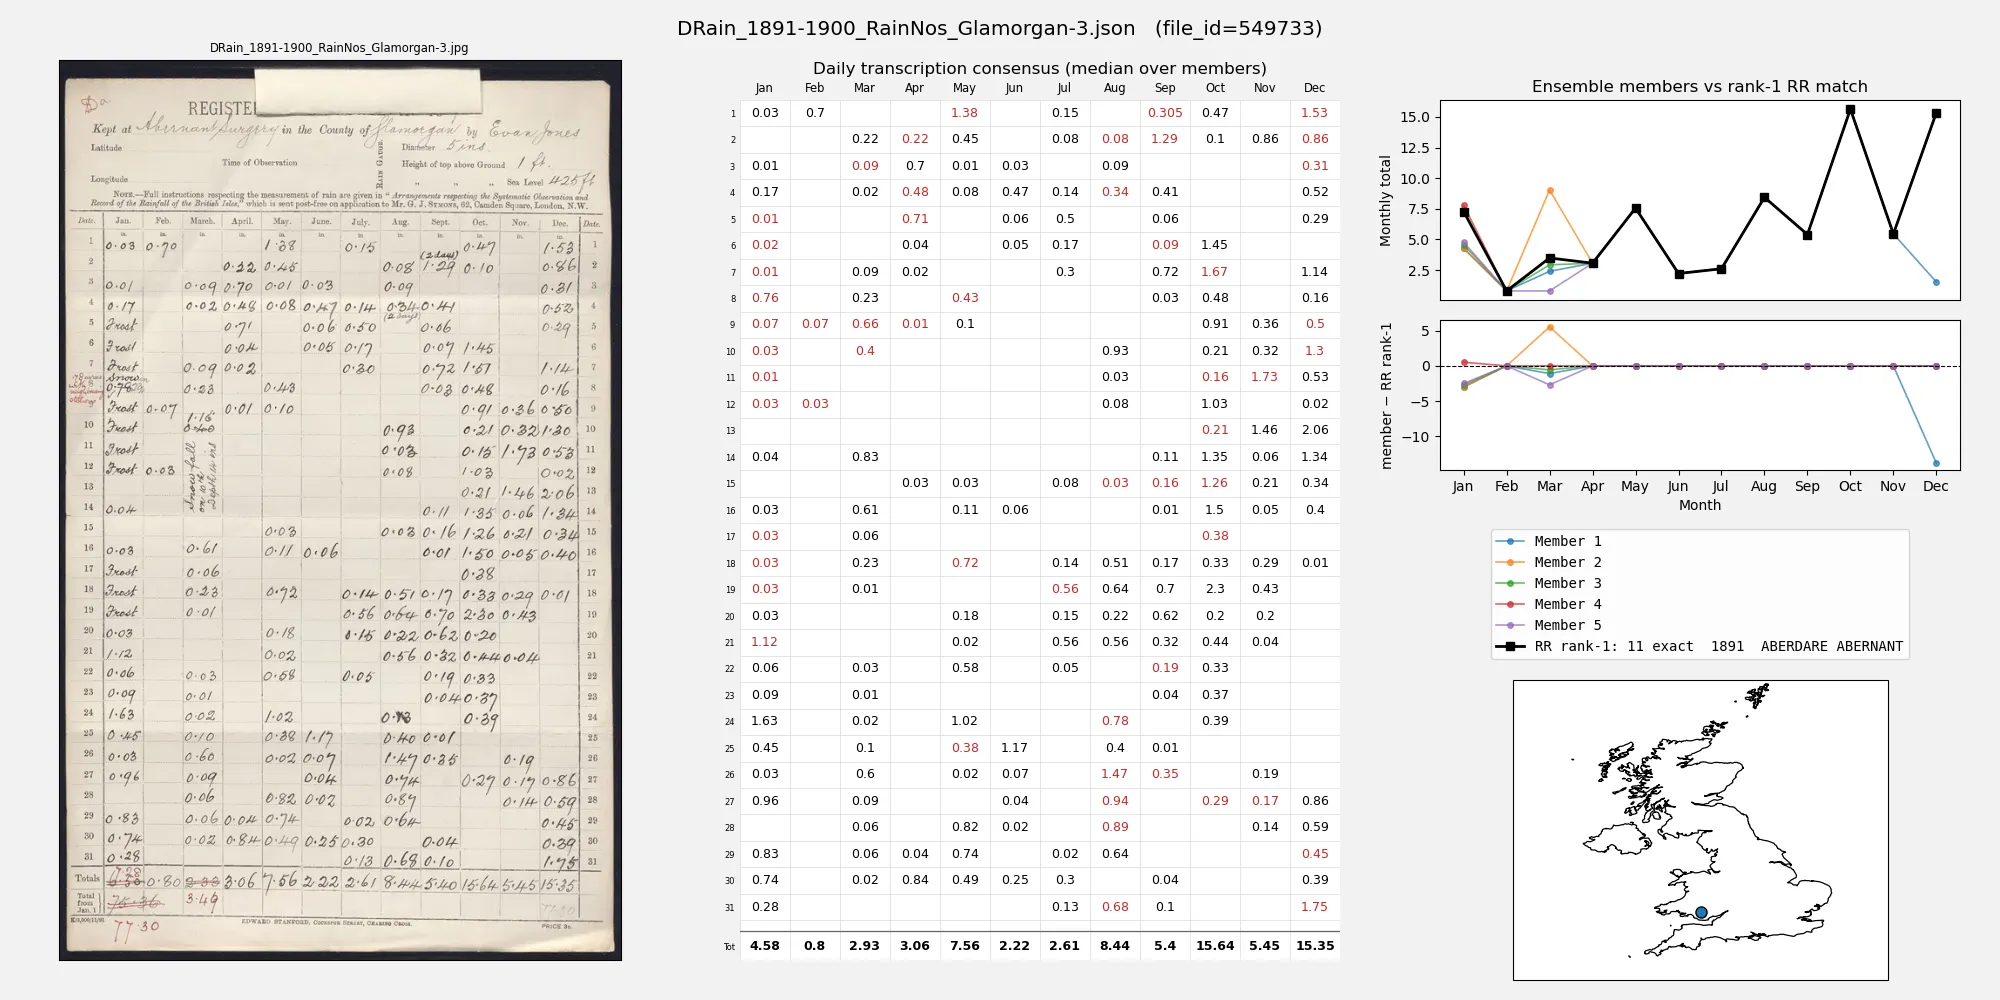

In [14]:
# Demonstrate the diagnostic plot script, rendered inline.

import importlib.util

import src.rainfall_rescue_sqlite as _pkg
from IPython.display import Image, display

# Locate the script relative to the repository root (parent of the src package).
repo_root = Path(_pkg.__file__).resolve().parents[2]
script_path = repo_root / "scripts" / "diagnostics" / "plot_image_consensus_metadata.py"

spec = importlib.util.spec_from_file_location("diag_plot", script_path)
diag_plot = importlib.util.module_from_spec(spec)
spec.loader.exec_module(diag_plot)

specifier ="DRain_1891-1900_RainNos_Glamorgan-3"
comparison_rank = 1  # Change to 2, 3, ... to compare with another rank.
output_path = Path(
    f"{os.getenv('PDIR')}/diagnostics/{specifier}_rank{comparison_rank}_diagnostic.webp"
)

diag_plot.build_figure(
    specifier=specifier,
    ensemble_dataset_root=ensemble_dataset_root,
    comparison_root=comparison_root,
    top_k=5,
    comparison_rank=comparison_rank,
    output_path=output_path,
)

print(f"Comparison rank: {comparison_rank}")
display(Image(filename=str(output_path)))


Session: 1
Rank plotted: 1
Total rank-1 rows: 540895


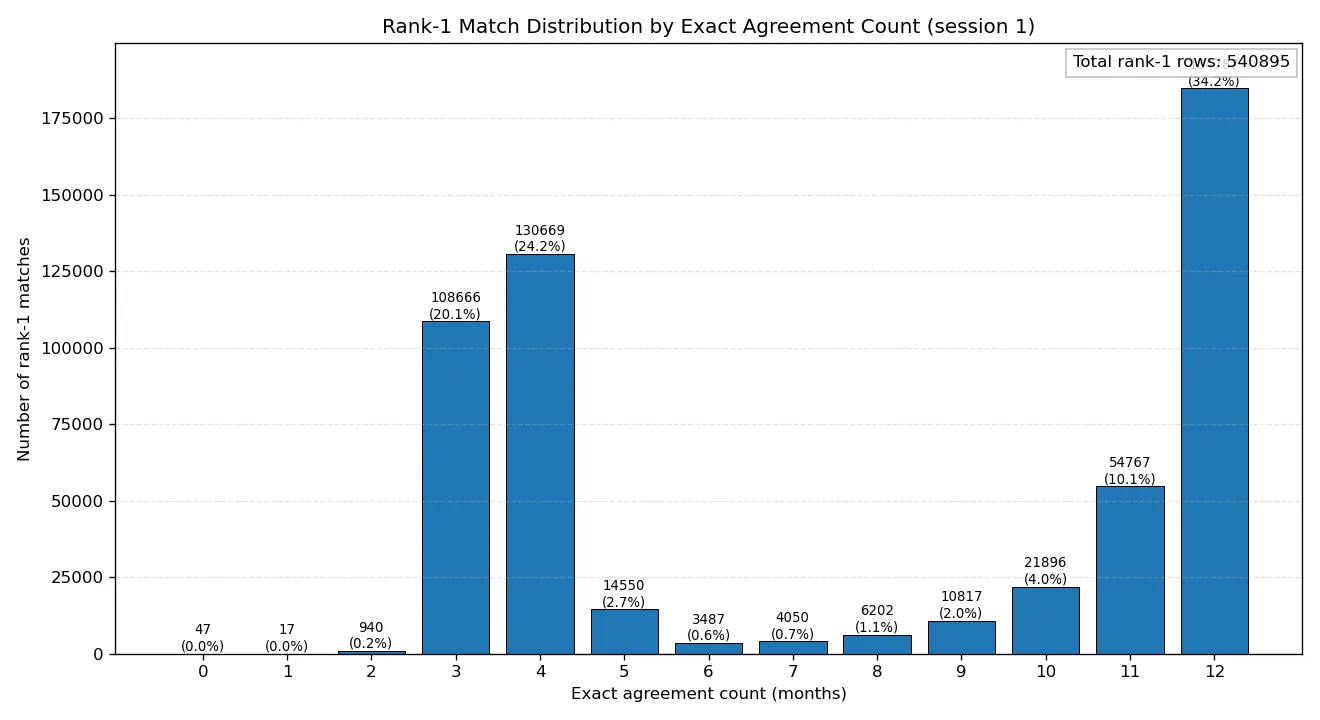

In [15]:
# Plot exact-agreement-count distribution for any match rank, rendered inline.

import importlib.util

from IPython.display import Image, display

rank_dist_script_path = repo_root / "scripts" / "diagnostics" / "plot_rank1_exact_agreement_distribution.py"

spec_rank_dist = importlib.util.spec_from_file_location("rank_dist_plot", rank_dist_script_path)
rank_dist_plot = importlib.util.module_from_spec(spec_rank_dist)
spec_rank_dist.loader.exec_module(rank_dist_plot)

rank_to_plot = 1
rank_dist_output_path = Path(
    f"{os.getenv('PDIR')}/diagnostics/rank{rank_to_plot}_exact_agreement_distribution.webp"
)

session_id, counts, total = rank_dist_plot.load_distribution_parquet(
    comparison_root,
    session_id=None,
    rank=rank_to_plot,
)
rank_dist_plot.plot_distribution(
    counts,
    total,
    session_id,
    rank_to_plot,
    rank_dist_output_path,
)

print(f"Session: {session_id}")
print(f"Rank plotted: {rank_to_plot}")
print(f"Total rank-{rank_to_plot} rows: {total}")

display(Image(filename=str(rank_dist_output_path)))

## Map of consensus daily rainfall for a single date

`scripts/diagnostics/plot_daily_rainfall_map.py` takes a calendar date
`YYYY-MM-DD` and plots every located station's **consensus** daily rainfall (the
median over the 5 ensemble members) on a map of the UK. A station is included
when its ensemble file was assigned a Rainfall-Rescue year matching the date's
year (`matched_year`) and has an assigned latitude/longitude.

From the command line:

```bash
python scripts/diagnostics/plot_daily_rainfall_map.py 1931-10-15 \
    --output daily_map.webp
```

The cell below imports the script's `build_figure` and renders it inline.

Date: 1931-11-03


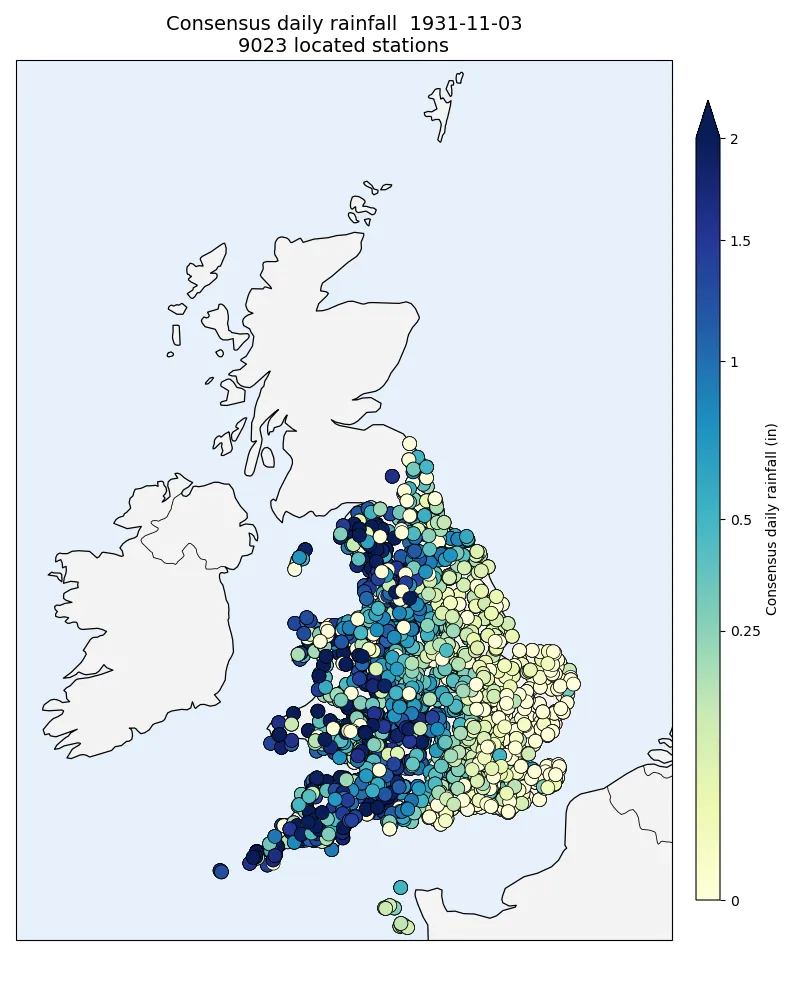

In [16]:
# Demonstrate the daily-rainfall map diagnostic, rendered inline.

import importlib.util
from datetime import date

from IPython.display import Image, display

daily_map_script_path = repo_root / "scripts" / "diagnostics" / "plot_daily_rainfall_map.py"

spec_daily_map = importlib.util.spec_from_file_location("daily_map_plot", daily_map_script_path)
daily_map_plot = importlib.util.module_from_spec(spec_daily_map)
spec_daily_map.loader.exec_module(daily_map_plot)

target_date = date(1931, 11, 3)  # Change to any YYYY-MM-DD with matched records.
daily_map_output_path = Path(
    f"{os.getenv('PDIR')}/diagnostics/daily_map_{target_date.isoformat()}.webp"
)

daily_map_plot.build_figure(
    target_date=target_date,
    ensemble_dataset_root=ensemble_dataset_root,
    comparison_root=comparison_root,
    output_path=daily_map_output_path,
)

print(f"Date: {target_date.isoformat()}")
display(Image(filename=str(daily_map_output_path)))


## Interactive daily rainfall map

`scripts/diagnostics/plot_daily_rainfall_interactive.py` draws the same map as an
interactive [Plotly](https://plotly.com/python/) figure. Hovering over a point
shows the **specifier** &mdash; the ensemble transcription's source file name
&mdash; that the data comes from, along with the station name and consensus
rainfall value (in inches).

**Clicking a station copies its specifier to the clipboard** and shows it in a
read-only box above the map (with a *Copy* button and a manual-select fallback).
The cell below renders the figure as HTML so this works inline in the notebook.

All located stations for the selected year are shown; those with no value for
the day are displayed at zero (dry/pale end of the colour scale).

The figure is also written to a self-contained HTML file that can be opened in a
browser without a running kernel.

In [1]:
# Demonstrate the interactive daily-rainfall map, rendered inline.

import importlib.util
import os
from datetime import date
from pathlib import Path

from IPython.display import HTML, display

import src.rainfall_rescue_sqlite as _pkg
from src.rainfall_rescue_sqlite.parquet_ingest import default_ensemble_parquet_root
from src.rainfall_rescue_sqlite.parquet_similarity import default_comparison_parquet_root

repo_root = Path(_pkg.__file__).resolve().parents[2]
ensemble_dataset_root = default_ensemble_parquet_root()
comparison_root = default_comparison_parquet_root()

daily_map_interactive_script_path = (
    repo_root / "scripts" / "diagnostics" / "plot_daily_rainfall_interactive.py"
)

spec_daily_map_interactive = importlib.util.spec_from_file_location(
    "daily_map_interactive_plot", daily_map_interactive_script_path
)
daily_map_interactive_plot = importlib.util.module_from_spec(spec_daily_map_interactive)
spec_daily_map_interactive.loader.exec_module(daily_map_interactive_plot)

target_date = date(1891, 11, 13)  # Change to any YYYY-MM-DD with matched records.
daily_map_interactive_output_path = Path(
    f"{os.getenv('PDIR')}/diagnostics/daily_map_{target_date.isoformat()}.html"
)

interactive_fig = daily_map_interactive_plot.build_figure(
    target_date=target_date,
    ensemble_dataset_root=ensemble_dataset_root,
    comparison_root=comparison_root,
    output_path=daily_map_interactive_output_path,
)

# Render as HTML (not fig.show()) so the click-to-copy JavaScript runs inline:
# click a station to copy its specifier to the clipboard.
display(HTML(daily_map_interactive_plot.inline_html(interactive_fig)))
